In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('ai_job_dataset1.csv')
df.shape  # (15000, 20)

(15000, 20)

In [3]:
df.info()
df.duplicated().sum()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   salary_local            15000 non-null  int64  
 5   experience_level        15000 non-null  object 
 6   employment_type         15000 non-null  object 
 7   company_location        15000 non-null  object 
 8   company_size            15000 non-null  object 
 9   employee_residence      15000 non-null  object 
 10  remote_ratio            15000 non-null  int64  
 11  required_skills         15000 non-null  object 
 12  education_required      15000 non-null  object 
 13  years_experience        15000 non-null  int64  
 14  industry                15000 non-null

job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
salary_local              0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_residence        0
remote_ratio              0
required_skills           0
education_required        0
years_experience          0
industry                  0
posting_date              0
application_deadline      0
job_description_length    0
benefits_score            0
company_name              0
dtype: int64

In [4]:
df.head(20)

,job_id,job_title,salary_usd,salary_currency,salary_local,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,Data Scientist,219728,USD,219728,EX,PT,Sweden,M,Sweden,0,"Python, Computer Vision, R, Docker",Associate,13,Transportation,9/23/2024,10/31/2024,1132,6.6,TechCorp Inc
1,AI00002,Head of AI,230237,JPY,25326070,EX,PT,Japan,L,Japan,50,"Kubernetes, MLOps, Tableau, Python",Bachelor,10,Transportation,7/26/2024,9/12/2024,2299,8.5,Cloud AI Solutions
2,AI00003,Data Engineer,128890,EUR,109557,EX,CT,Germany,S,Germany,100,"Spark, Scala, Hadoop, PyTorch, GCP",Bachelor,12,Automotive,1/19/2025,3/28/2025,1329,5.5,Quantum Computing Inc
3,AI00004,Computer Vision Engineer,96349,USD,96349,MI,FL,Finland,L,Finland,50,"MLOps, Linux, Tableau, Python",PhD,2,Automotive,7/20/2024,9/6/2024,1132,6.8,Cognitive Computing
4,AI00005,Robotics Engineer,63065,EUR,53605,EN,FT,France,S,France,100,"R, Scala, SQL, GCP, Python",Associate,0,Finance,3/16/2025,5/9/2025,2011,9.3,Advanced Robotics
5,AI00006,Data Scientist,111794,SGD,145332,SE,CT,Singapore,S,Norway,50,"NLP, MLOps, TensorFlow",Master,7,Technology,11/10/2024,1/20/2025,1021,5.1,Cloud AI Solutions
6,AI00007,AI Consultant,113897,CAD,142371,SE,PT,Canada,L,Poland,50,"PyTorch, Linux, NLP",Associate,9,Gaming,2/29/2024,4/21/2024,2268,7.4,AI Innovations
7,AI00008,Head of AI,168639,AUD,227663,SE,FT,Australia,L,Vietnam,100,"Spark, SQL, Tableau, Computer Vision, Linux",Associate,9,Consulting,2/26/2024,3/17/2024,1497,5.5,TechCorp Inc
8,AI00009,Data Scientist,92624,JPY,10188640,MI,FT,Japan,L,Japan,50,"Kubernetes, SQL, Docker, Deep Learning",Bachelor,4,Government,8/18/2024,10/3/2024,1724,9.5,DataVision Ltd
9,AI00010,Machine Learning Engineer,215627,GBP,161720,EX,FT,United Kingdom,M,United Kingdom,50,"Git, Scala, GCP",PhD,10,Government,1/18/2025,3/20/2025,902,7.8,DeepTech Ventures


In [5]:
df.dtypes

job_id                     object
job_title                  object
salary_usd                  int64
salary_currency            object
salary_local                int64
experience_level           object
employment_type            object
company_location           object
company_size               object
employee_residence         object
remote_ratio                int64
required_skills            object
education_required         object
years_experience            int64
industry                   object
posting_date               object
application_deadline       object
job_description_length      int64
benefits_score            float64
company_name               object
dtype: object

In [6]:
df['application_deadline'] = pd.to_datetime(df['application_deadline'] , errors='coerce')
df['posting_date'] = pd.to_datetime(df['posting_date'] , errors='coerce')

In [7]:
#creating new column to check how many days to apply
df['days_to_apply'] = (df['application_deadline'] - df['posting_date']).dt.days

In [8]:
#new columns are created 
df['post_month'] = df['posting_date'].dt.month
df['post_year'] = df['posting_date'].dt.year
df['post_quarter'] = df['posting_date'].dt.quarter

In [9]:
# Count number of skills required
df['skill_count'] = df['required_skills'].apply(lambda x: len(x.split(',')))

premium_skills = ['PyTorch', 'TensorFlow', 'Kubernetes', 'MLOps', 'Deep Learning',
                  'NLP', 'GCP', 'Spark', 'Docker', 'Computer Vision']

def has_premium_skill(skills_str):
    skills = [s.strip() for s in skills_str.split(',')]
    return int(any(s in premium_skills for s in skills))

df['has_premium_skill'] = df['required_skills'].apply(has_premium_skill)

In [10]:
# Higher risk = more routine, lower salary, less specialized
# Define logic-based risk score (0 = safe, 1 = high risk)

# Risk factors:
#   - Lower experience needed = higher risk
#   - Lower salary = higher risk
#   - Fewer required skills = higher risk
#   - No premium skills = higher risk
#   - Non-specialized job title = higher risk

risk_job_titles = ['Data Analyst', 'AI Specialist', 'AI Consultant']

exp_risk = {'EN': 0.8, 'MI': 0.5, 'SE': 0.3, 'EX': 0.1}
df['exp_risk'] = df['experience_level'].map(exp_risk)

salary_risk = 1 - (df['salary_usd'] - df['salary_usd'].min()) / (df['salary_usd'].max() - df['salary_usd'].min())
skill_risk = 1 - (df['skill_count'] - df['skill_count'].min()) / (df['skill_count'].max() - df['skill_count'].min())
premium_risk = 1 - df['has_premium_skill']
title_risk = df['job_title'].apply(lambda x: 0.6 if x in risk_job_titles else 0.2)

# Weighted composite risk score
df['ai_automation_risk'] = (
    0.30 * salary_risk +
    0.25 * df['exp_risk'] +
    0.20 * skill_risk +
    0.15 * premium_risk +
    0.10 * title_risk
)

# Scale to 0–100
df['ai_automation_risk'] = (df['ai_automation_risk'] * 100).round(2)

In [11]:
le = LabelEncoder()

cat_cols = ['job_title', 'experience_level', 'employment_type',
            'company_location', 'company_size', 'employee_residence',
            'education_required', 'industry', 'company_name']

df_encoded = df.copy()
for col in cat_cols:
    df_encoded[col + '_enc'] = le.fit_transform(df[col])

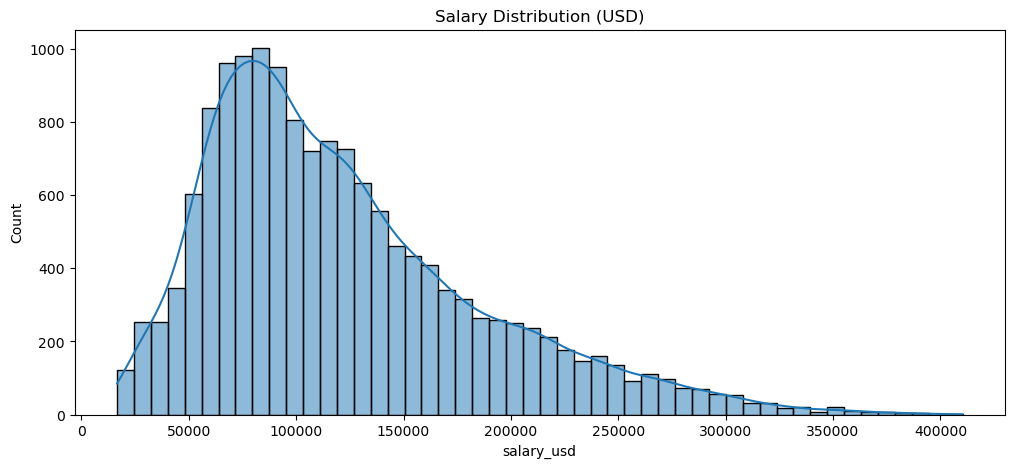

In [12]:
 #Salary distribution
plt.figure(figsize=(12,5))
sns.histplot(df['salary_usd'], bins=50, kde=True)
plt.title('Salary Distribution (USD)')
plt.show()

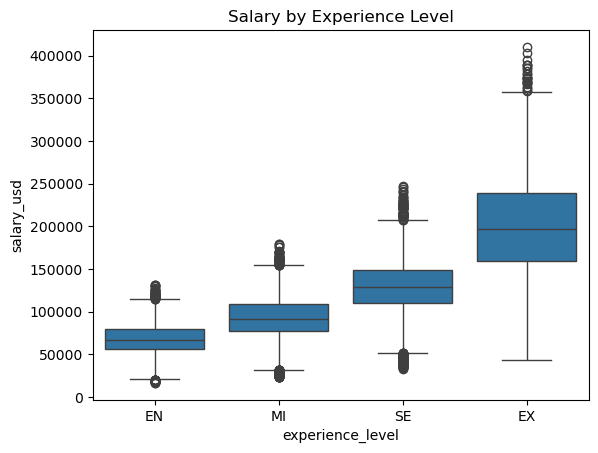

In [13]:
# Salary by experience level
sns.boxplot(x='experience_level', y='salary_usd', data=df,
            order=['EN','MI','SE','EX'])
plt.title('Salary by Experience Level')
plt.show()

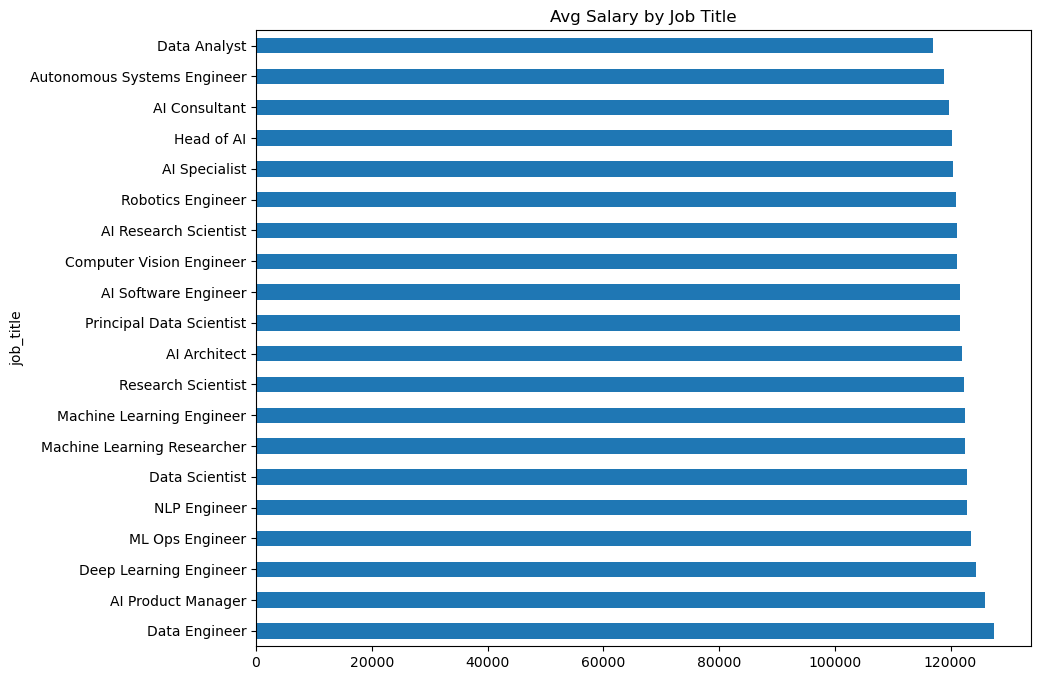

In [14]:
# Average salary by job title
df.groupby('job_title')['salary_usd'].mean().sort_values(ascending=False).plot(
    kind='barh', figsize=(10, 8), title='Avg Salary by Job Title')
plt.show()

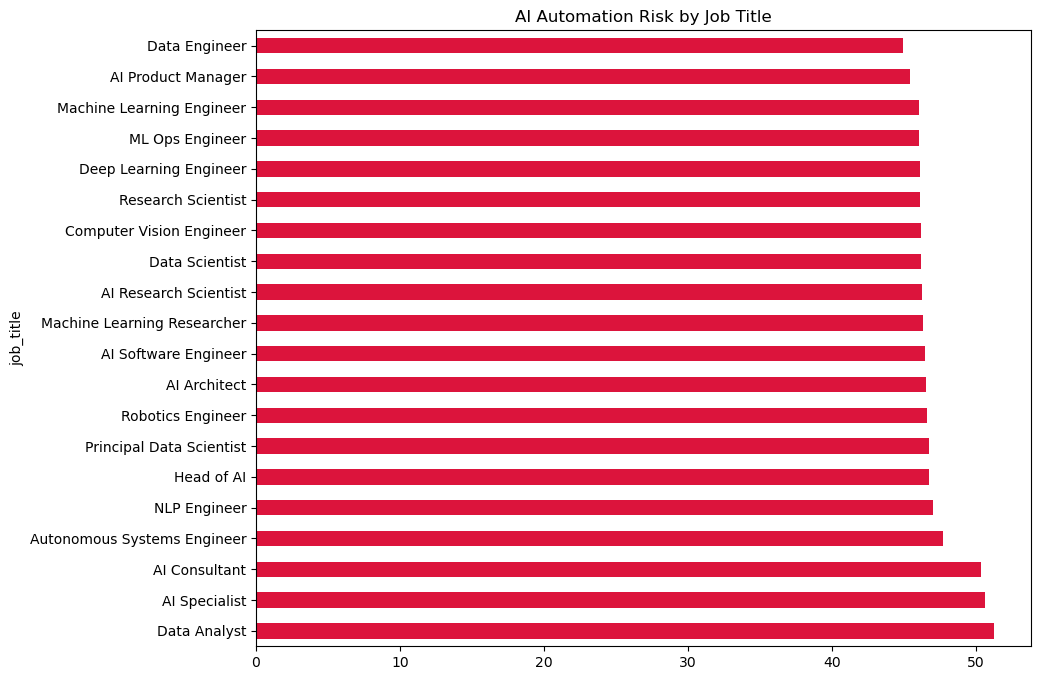

In [15]:
# AI Automation Risk by job title
df.groupby('job_title')['ai_automation_risk'].mean().sort_values(ascending=False).plot(
    kind='barh', color='crimson', figsize=(10, 8),
    title='AI Automation Risk by Job Title')
plt.show()


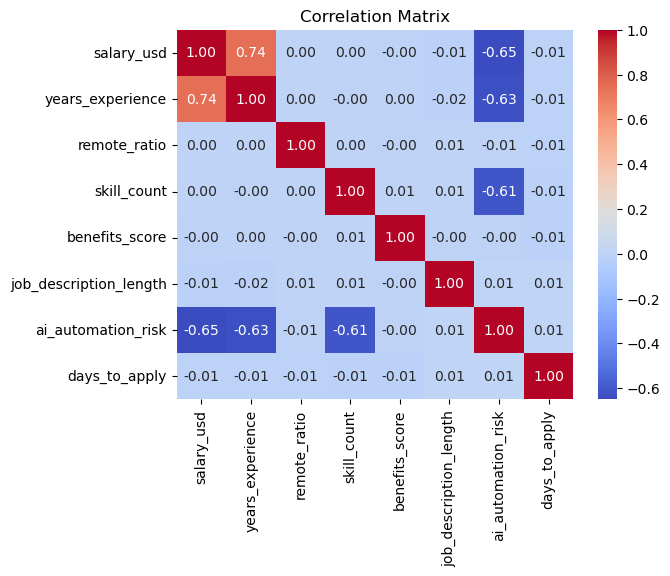

In [16]:
# Correlation heatmap
num_cols = ['salary_usd', 'years_experience', 'remote_ratio',
            'skill_count', 'benefits_score', 'job_description_length',
            'ai_automation_risk', 'days_to_apply']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [17]:
df.head(9)

,job_id,job_title,salary_usd,salary_currency,salary_local,experience_level,employment_type,company_location,company_size,employee_residence,...,benefits_score,company_name,days_to_apply,post_month,post_year,post_quarter,skill_count,has_premium_skill,exp_risk,ai_automation_risk
0,AI00001,Data Scientist,219728,USD,219728,EX,PT,Sweden,M,Sweden,...,6.6,TechCorp Inc,38,9,2024,3,4,1,0.1,29.02
1,AI00002,Head of AI,230237,JPY,25326070,EX,PT,Japan,L,Japan,...,8.5,Cloud AI Solutions,48,7,2024,3,4,1,0.1,28.22
2,AI00003,Data Engineer,128890,EUR,109557,EX,CT,Germany,S,Germany,...,5.5,Quantum Computing Inc,68,1,2025,1,5,1,0.1,25.94
3,AI00004,Computer Vision Engineer,96349,USD,96349,MI,FL,Finland,L,Finland,...,6.8,Cognitive Computing,48,7,2024,3,4,1,0.5,48.42
4,AI00005,Robotics Engineer,63065,EUR,53605,EN,FT,France,S,France,...,9.3,Advanced Robotics,54,3,2025,1,5,1,0.8,48.46
5,AI00006,Data Scientist,111794,SGD,145332,SE,CT,Singapore,S,Norway,...,5.1,Cloud AI Solutions,71,11,2024,4,3,1,0.3,52.25
6,AI00007,AI Consultant,113897,CAD,142371,SE,PT,Canada,L,Poland,...,7.4,AI Innovations,52,2,2024,1,3,1,0.3,56.09
7,AI00008,Head of AI,168639,AUD,227663,SE,FT,Australia,L,Vietnam,...,5.5,TechCorp Inc,20,2,2024,1,5,1,0.3,27.91
8,AI00009,Data Scientist,92624,JPY,10188640,MI,FT,Japan,L,Japan,...,9.5,DataVision Ltd,46,8,2024,3,4,1,0.5,48.71


In [20]:
df.shape

(15000, 28)

In [21]:
feature_cols = [
    'job_title_enc', 'experience_level_enc', 'employment_type_enc',
    'company_location_enc', 'company_size_enc', 'employee_residence_enc',
    'education_required_enc', 'industry_enc', 'company_name_enc',
    'remote_ratio', 'years_experience', 'skill_count',
    'has_premium_skill', 'job_description_length', 'benefits_score',
    'post_month', 'post_year', 'post_quarter', 'days_to_apply'
]

X = df_encoded[feature_cols]
y = df_encoded['salary_usd']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (12000, 19), Test size: (3000, 19)


In [22]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [23]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    if name in ['Random Forest', 'Gradient Boosting']:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"{name}: MAE=${mae:,.0f} | RMSE=${rmse:,.0f} | R²={r2:.4f}")

results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
print(results_df)

Linear Regression: MAE=$27,178 | RMSE=$38,438 | R²=0.6313
Ridge Regression: MAE=$27,178 | RMSE=$38,438 | R²=0.6313
Lasso Regression: MAE=$27,177 | RMSE=$38,438 | R²=0.6313
Random Forest: MAE=$15,635 | RMSE=$21,871 | R²=0.8806
Gradient Boosting: MAE=$15,712 | RMSE=$21,519 | R²=0.8845
                            MAE          RMSE        R2
Gradient Boosting  15712.130887  21518.513025  0.884451
Random Forest      15635.495820  21870.913041  0.880635
Linear Regression  27177.611459  38437.584838  0.631315
Ridge Regression   27177.550949  38437.681277  0.631313
Lasso Regression   27177.326710  38437.707678  0.631313


In [24]:
# Tune Random Forest (likely best performer)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
y_pred_best = best_rf.predict(X_test)

print(f"Best Params: {rf_grid.best_params_}")
print(f"Best R²: {r2_score(y_test, y_pred_best):.4f}")
print(f"Best MAE: ${mean_absolute_error(y_test, y_pred_best):,.0f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best R²: 0.8829
Best MAE: $15,548


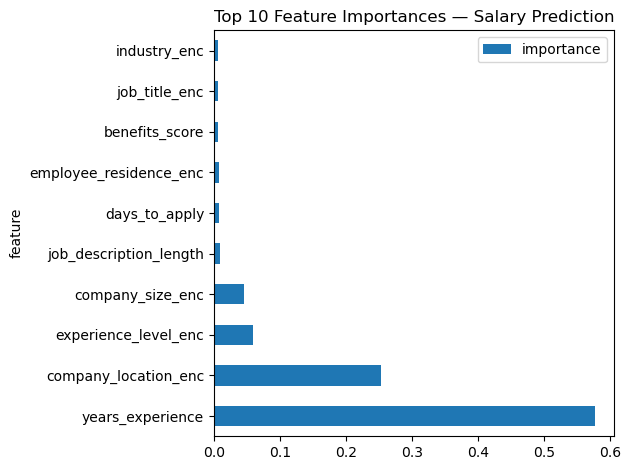

In [25]:
feat_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

feat_imp.head(10).plot(
    x='feature', y='importance', kind='barh',
    title='Top 10 Feature Importances — Salary Prediction')
plt.tight_layout()
plt.show()

In [26]:
# Target: ai_automation_risk (continuous 0–100)
y_risk = df_encoded['ai_automation_risk']

X_r_train, X_r_test, y_r_train, y_r_test = train_test_split(
    X, y_risk, test_size=0.2, random_state=42)

from sklearn.ensemble import GradientBoostingRegressor
gb_risk = GradientBoostingRegressor(n_estimators=150, max_depth=5, random_state=42)
gb_risk.fit(X_r_train, y_r_train)

y_risk_pred = gb_risk.predict(X_r_test)
print(f"Automation Risk Prediction R²: {r2_score(y_r_test, y_risk_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_r_test, y_risk_pred):.2f}")

Automation Risk Prediction R²: 0.9877
MAE: 1.20


In [27]:
# Predict salary and risk on entire dataset
df_encoded['predicted_salary_usd'] = best_rf.predict(X)
df_encoded['predicted_automation_risk'] = gb_risk.predict(X)

# Prediction error column
df_encoded['salary_prediction_error'] = (
    df_encoded['salary_usd'] - df_encoded['predicted_salary_usd'])

# Risk category column (for Power BI slicing)
def risk_category(score):
    if score < 30: return 'Low Risk'
    elif score < 60: return 'Medium Risk'
    else: return 'High Risk'

df_encoded['risk_category'] = df_encoded['predicted_automation_risk'].apply(risk_category)

In [28]:
# Keep original label columns + new prediction columns
output_cols = [
    'job_id', 'job_title', 'salary_usd', 'predicted_salary_usd',
    'salary_prediction_error', 'salary_currency', 'experience_level',
    'employment_type', 'company_location', 'company_size',
    'employee_residence', 'remote_ratio', 'education_required',
    'years_experience', 'industry', 'company_name',
    'skill_count', 'has_premium_skill', 'benefits_score',
    'job_description_length', 'days_to_apply', 'post_month',
    'post_year', 'post_quarter', 'ai_automation_risk',
    'predicted_automation_risk', 'risk_category'
]

df_final = df_encoded[output_cols].copy()
df_final.to_csv('ai_jobs_predictions_final.csv', index=False)
print(f"Exported {df_final.shape[0]} rows to ai_jobs_predictions_final.csv")

Exported 15000 rows to ai_jobs_predictions_final.csv


In [29]:
feat_imp.to_csv('feature_importance.csv', index=False)

In [30]:
results_df.to_csv('model_performance_summary.csv')

In [ ]:
df.shape